# Team Delta
## Names:- Varun Biren Majithia (Student ID:-200532798),
## Samarth Deshpande (Student ID:- 200532782), 
## Jannatul Ferdousi Rajoni (200530077)

## Importing necessary packages

In [1]:
# --- Importing Libraries ---
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# BeautifulSoup and Text Preprocessing
from bs4 import BeautifulSoup
import contractions

# NLTK Libraries
import nltk
from nltk.corpus import words, stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn modules
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc, mean_absolute_error, mean_squared_error
)
from sklearn.feature_extraction.text import TfidfVectorizer

# XGBoost
from xgboost import XGBClassifier

# Category Encoders
from category_encoders import TargetEncoder

# SHAP for Explainability
import shap

# --- Download NLTK Resources ---
nltk.download('words')
nltk.download('wordnet')
nltk.download('stopwords')

# --- Setup ---
english_vocab = set(words.words())
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\samar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\samar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Dataset Preview

In [2]:
# Load the dataset
data = pd.read_csv('fake_job_postings.csv')

# Display the first few rows of the dataset
print("Dataset Preview:")
print(data.head())

Dataset Preview:
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         desc

## Dataset Infomation

In [3]:
# Dataset Information
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  o

In [4]:
print("\nDataset Description (Numerical Columns):")
data.describe()


Dataset Description (Numerical Columns):


,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


## Exploring data

In [5]:
# Count the number of columns with dtype 'object'
object_cols = data.select_dtypes(include=['object']).columns
num_object_cols = len(object_cols)

# Count the number of columns with dtype 'int64'
int_cols = data.select_dtypes(include=['int64']).columns
num_int_cols = len(int_cols)

print(f"Number of columns with object dtype: {num_object_cols}")
print(f"Number of columns with int64 dtype: {num_int_cols}")

Number of columns with object dtype: 13
Number of columns with int64 dtype: 5


## Checking for missing values

In [6]:
# Check for missing values
missing_values = data.isnull().sum()
print("\nMissing Values in Each Column:")
print(missing_values[missing_values > 0])


Missing Values in Each Column:
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
dtype: int64


## Finding out null values

In [7]:
# View percentage of missing values per column
print('Percent of Null Values in Each Column:\n')
print(data.isnull().mean() * 100)

Percent of Null Values in Each Column:

job_id                  0.000000
title                   0.000000
location                1.935123
department             64.580537
salary_range           83.959732
company_profile        18.501119
description             0.005593
requirements           15.078300
benefits               40.335570
telecommuting           0.000000
has_company_logo        0.000000
has_questions           0.000000
employment_type        19.412752
required_experience    39.429530
required_education     45.329978
industry               27.421700
function               36.101790
fraudulent              0.000000
dtype: float64


In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Analyze categorical columns
categorical_cols = ['telecommuting', 'has_company_logo', 'has_questions', 
                    'employment_type', 'required_experience', 'required_education', 
                    'industry', 'function']
print("\nUnique Value Counts for Categorical Columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(data[col].value_counts())


Unique Value Counts for Categorical Columns:

telecommuting:
telecommuting
0    17113
1      767
Name: count, dtype: int64

has_company_logo:
has_company_logo
1    14220
0     3660
Name: count, dtype: int64

has_questions:
has_questions
0    9088
1    8792
Name: count, dtype: int64

employment_type:
employment_type
Full-time    11620
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

required_experience:
required_experience
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

required_education:
required_education
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Co

## Class Distribution

In [10]:
# Check class distribution (fraudulent vs non-fraudulent jobs)
if 'fraudulent' in data.columns:
    class_distribution = data['fraudulent'].value_counts()
    print("\nClass Distribution (Fraudulent vs Non-Fraudulent):")
    print(class_distribution)


Class Distribution (Fraudulent vs Non-Fraudulent):
fraudulent
0    17014
1      866
Name: count, dtype: int64


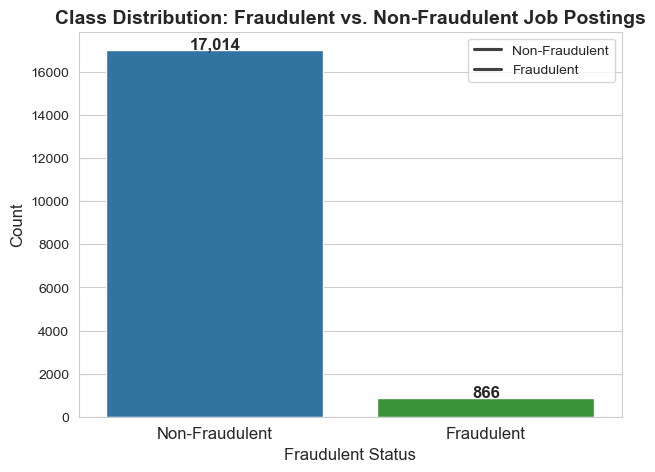

In [11]:
# Set industry-standard style
sns.set_style("whitegrid")

# Define colors (blue & green - industry standard for trust & safety)
colors = ["#1f77b4", "#2ca02c"]  # Blue for Non-Fraudulent, Green for Fraudulent

# Create figure
plt.figure(figsize=(7, 5))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette=colors)

# Add annotations on bars
for i, val in enumerate(class_distribution.values):
    plt.text(i, val + 50, f"{val:,}", ha="center", fontsize=12, fontweight="bold")

# Set title and labels
plt.title("Class Distribution: Fraudulent vs. Non-Fraudulent Job Postings", fontsize=14, fontweight="bold")
plt.xlabel("Fraudulent Status", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Set custom x-axis labels
plt.xticks(ticks=[0, 1], labels=["Non-Fraudulent", "Fraudulent"], fontsize=12)

# Add a legend
plt.legend(["Non-Fraudulent", "Fraudulent"], loc="upper right", frameon=True)

# Show plot
plt.show()


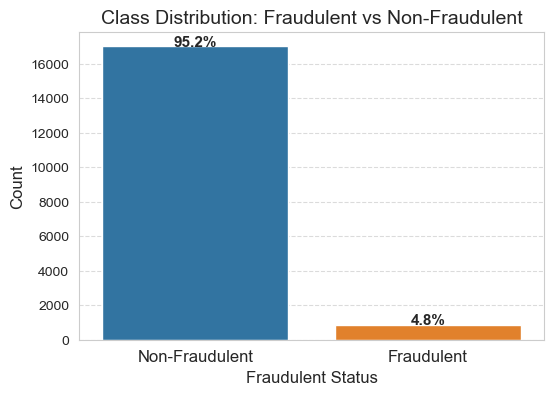

In [12]:
# Class distribution
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=data['fraudulent'].value_counts().index, 
                 y=data['fraudulent'].value_counts().values, 
                 palette=["#1f77b4", "#ff7f0e"])  # Blue for non-fraud, orange for fraud

plt.title("Class Distribution: Fraudulent vs Non-Fraudulent", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Non-Fraudulent", "Fraudulent"], fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xlabel("Fraudulent Status", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels
total = len(data)
for p in ax.patches:
    ax.annotate(f"{100 * p.get_height() / total:.1f}%", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha="center", fontsize=11, fontweight="bold")

plt.show()


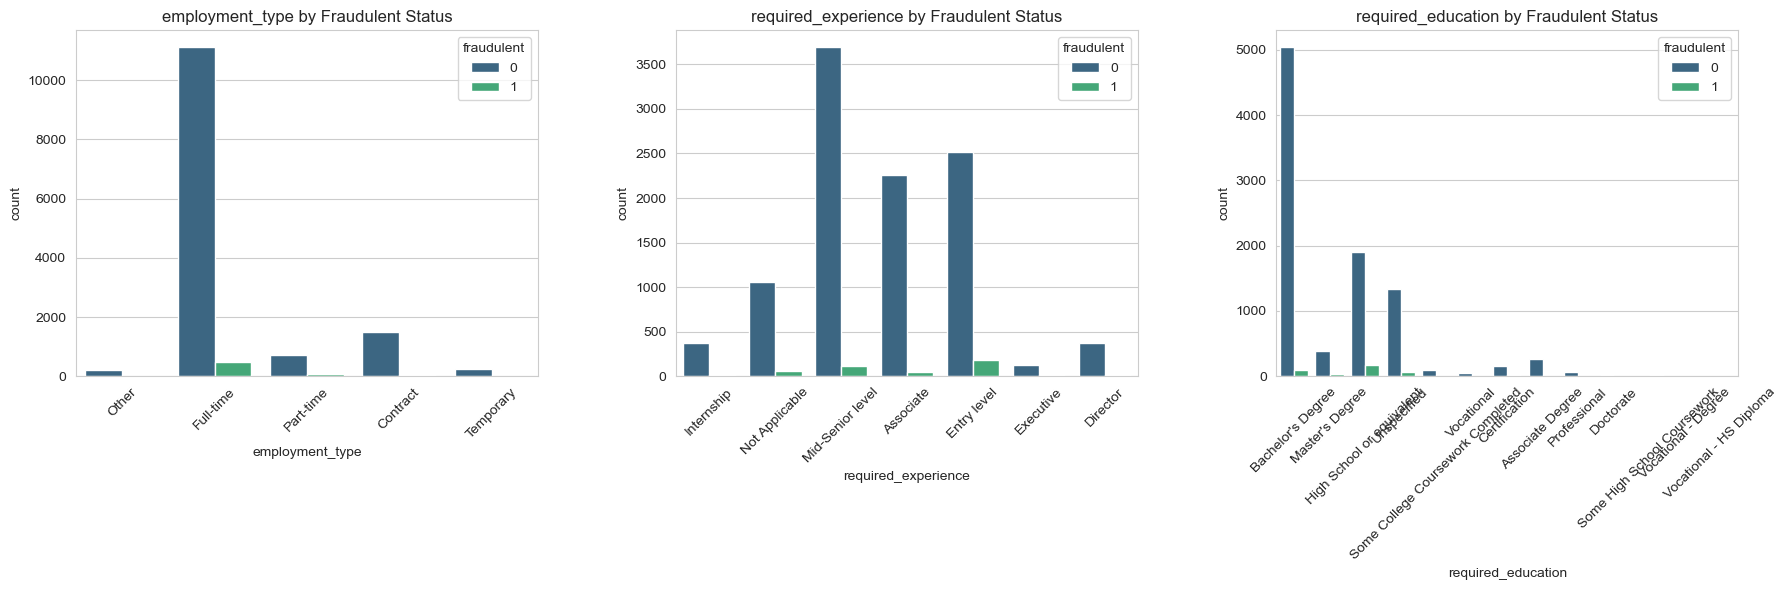

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns
categorical_columns = ['employment_type', 'required_experience', 'required_education']

# Create a figure with a larger size
plt.figure(figsize=(18, 6))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(1, len(categorical_columns), i)
    sns.countplot(x=col, hue='fraudulent', data=data, palette='viridis')
    plt.title(f"{col} by Fraudulent Status")
    plt.xticks(rotation=45)  # Rotate x-axis labels to avoid overlap

# Adjust layout to prevent overlapping
plt.tight_layout()

# Adjust subplot spacing for better visibility
plt.subplots_adjust(wspace=0.3)

plt.show()


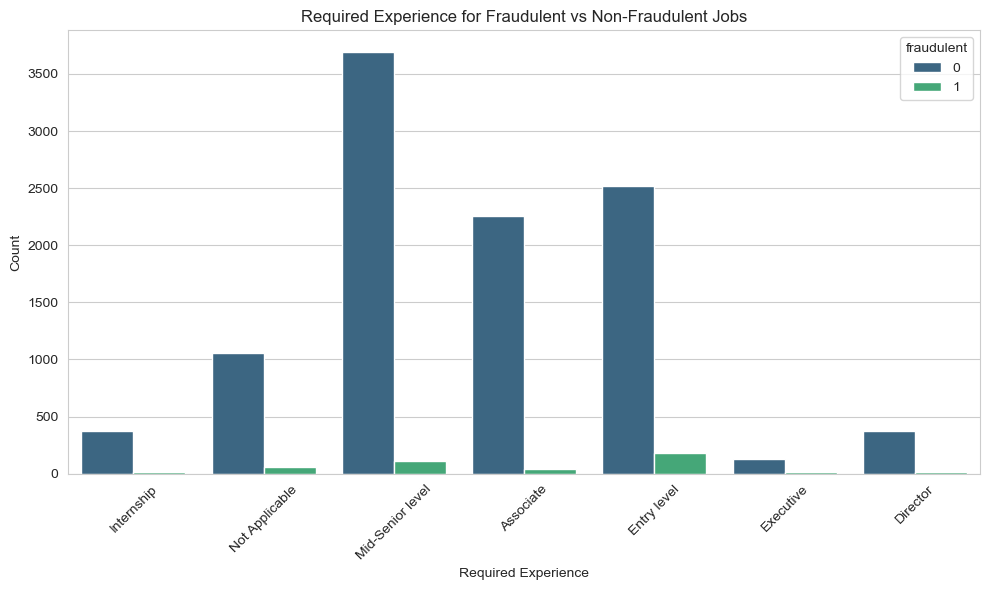

In [14]:
# Plot required experience by fraudulent status
plt.figure(figsize=(10, 6))
sns.countplot(x='required_experience', hue='fraudulent', data=data, palette='viridis')
plt.title('Required Experience for Fraudulent vs Non-Fraudulent Jobs')
plt.xticks(rotation=45)
plt.xlabel('Required Experience')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


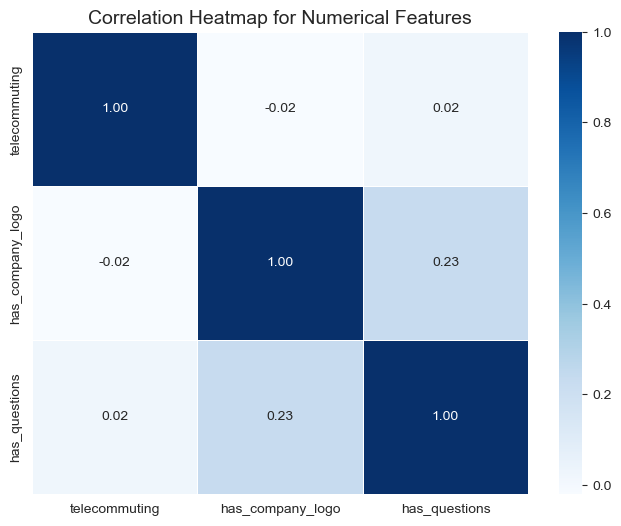

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numerical_columns = ['telecommuting', 'has_company_logo', 'has_questions']

# Calculate correlation matrix
corr = data[numerical_columns].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap for Numerical Features", fontsize=14)
plt.show()


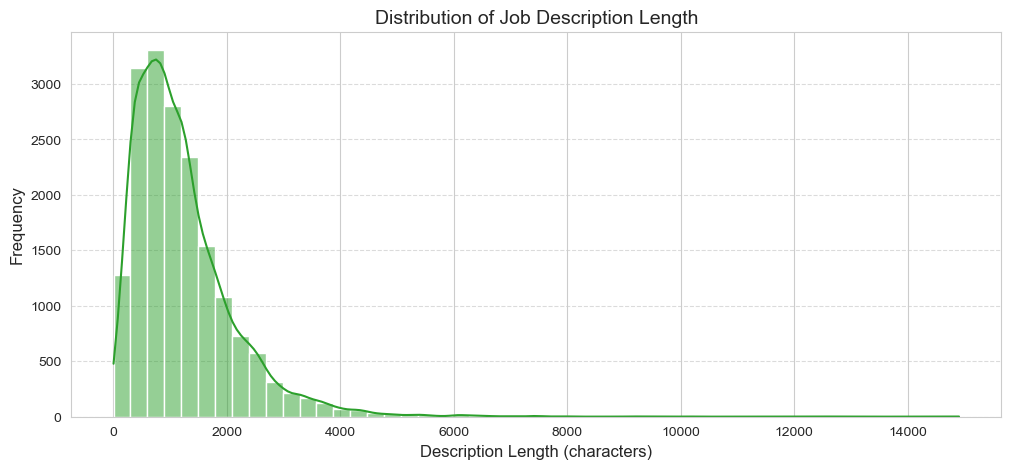

In [16]:
plt.figure(figsize=(12, 5))
sns.histplot(data['description'].str.len(), bins=50, color='#2ca02c', kde=True)  # Green
plt.title("Distribution of Job Description Length", fontsize=14)
plt.xlabel("Description Length (characters)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


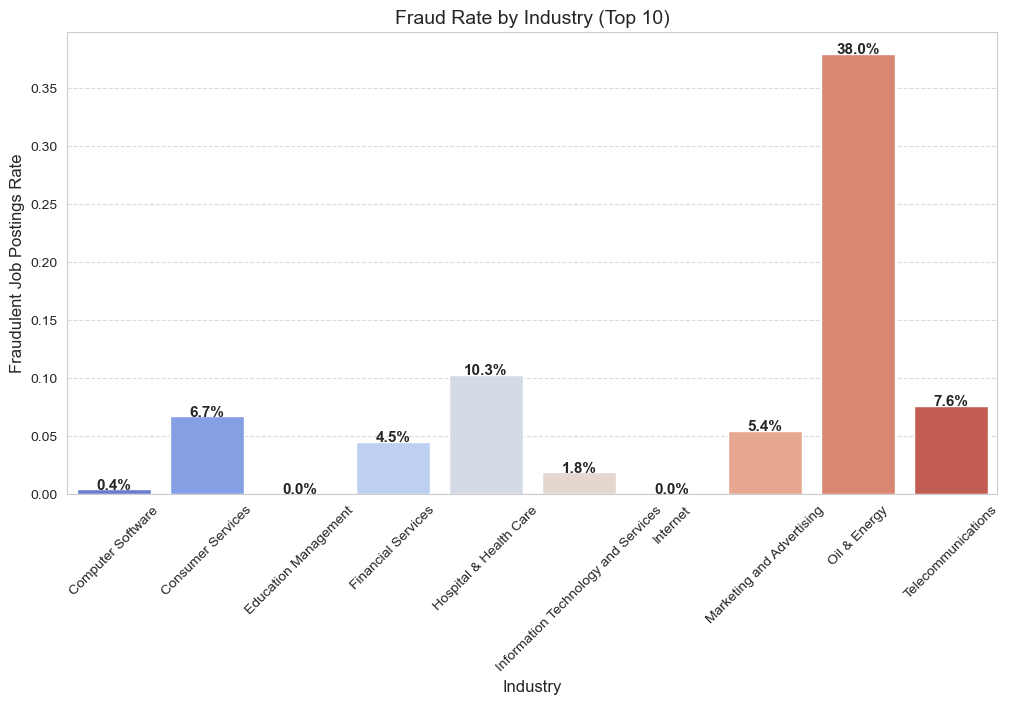

In [17]:
top_industries = data['industry'].value_counts().nlargest(10).index
fraud_rates = data[data['industry'].isin(top_industries)].groupby("industry")["fraudulent"].mean()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=fraud_rates.index, y=fraud_rates.values, palette="coolwarm")

plt.title("Fraud Rate by Industry (Top 10)", fontsize=14)
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Fraudulent Job Postings Rate", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add percentage labels
for p in ax.patches:
    ax.annotate(f"{100 * p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha="center", fontsize=11, fontweight="bold")

plt.show()


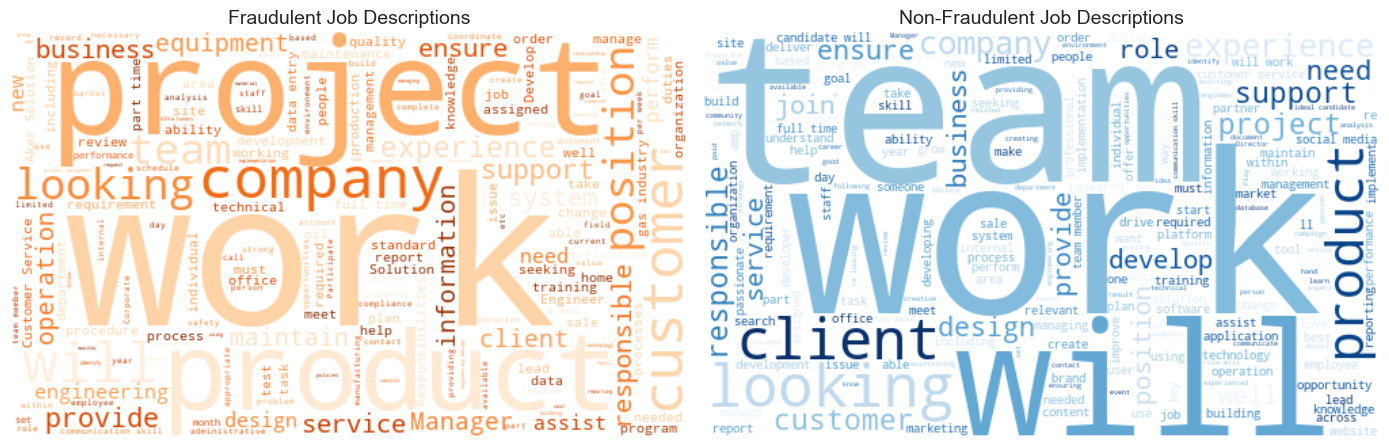

In [18]:
from wordcloud import WordCloud

# Generate word clouds
fraud_text = " ".join(data[data["fraudulent"] == 1]["description"].dropna())
non_fraud_text = " ".join(data[data["fraudulent"] == 0]["description"].dropna())

plt.figure(figsize=(14, 6))

# Fraudulent Jobs Word Cloud
plt.subplot(1, 2, 1)
wc = WordCloud(width=500, height=300, background_color="white", colormap="Oranges").generate(fraud_text)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Fraudulent Job Descriptions", fontsize=14)

# Non-Fraudulent Jobs Word Cloud
plt.subplot(1, 2, 2)
wc = WordCloud(width=500, height=300, background_color="white", colormap="Blues").generate(non_fraud_text)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Non-Fraudulent Job Descriptions", fontsize=14)

plt.tight_layout()
plt.show()


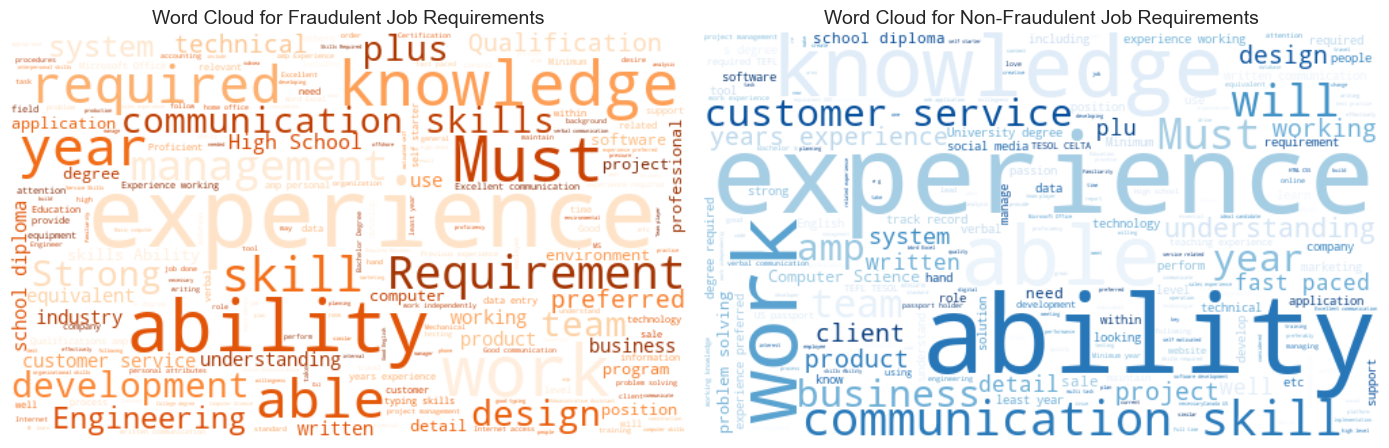

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine text from the 'requirements' column for fraudulent and non-fraudulent jobs
fraud_text = " ".join(job for job in data[data["fraudulent"] == 1]["requirements"].dropna())
non_fraud_text = " ".join(job for job in data[data["fraudulent"] == 0]["requirements"].dropna())

plt.figure(figsize=(14, 6))

# Fraudulent Jobs Word Cloud
plt.subplot(1, 2, 1)
fraud_wc = WordCloud(width=500, height=300, background_color="white", colormap="Oranges").generate(fraud_text)
plt.imshow(fraud_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Fraudulent Job Requirements", fontsize=14)

# Non-Fraudulent Jobs Word Cloud
plt.subplot(1, 2, 2)
non_fraud_wc = WordCloud(width=500, height=300, background_color="white", colormap="Blues").generate(non_fraud_text)
plt.imshow(non_fraud_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Non-Fraudulent Job Requirements", fontsize=14)

plt.tight_layout()
plt.show()


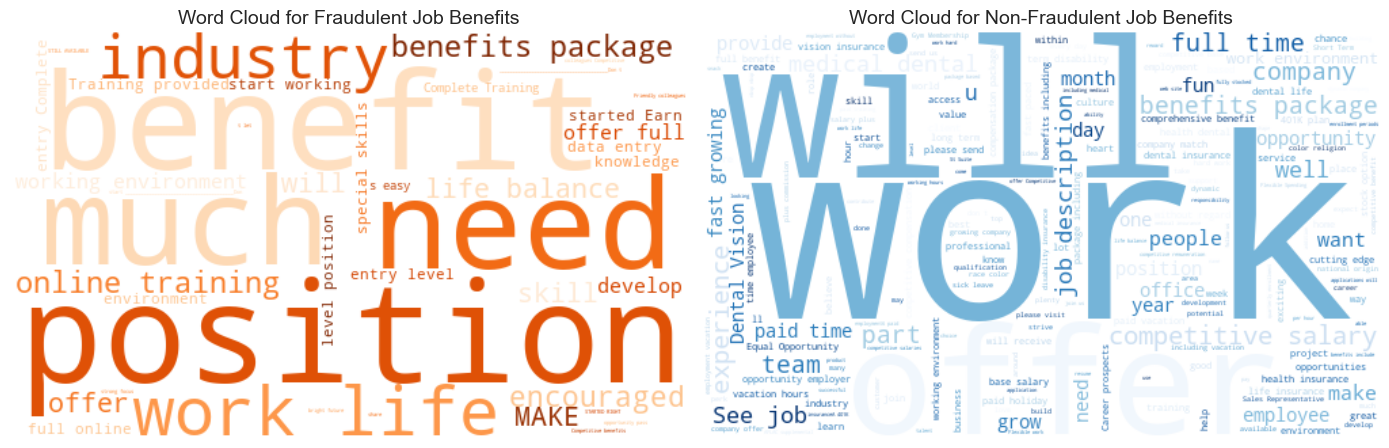

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine text from the 'benefits' column for fraudulent and non-fraudulent jobs
fraud_benefits_text = " ".join(job for job in data[data["fraudulent"] == 1]["benefits"].dropna())
non_fraud_benefits_text = " ".join(job for job in data[data["fraudulent"] == 0]["benefits"].dropna())

plt.figure(figsize=(14, 6))

# Fraudulent Jobs Word Cloud
plt.subplot(1, 2, 1)
fraud_benefits_wc = WordCloud(width=500, height=300, background_color="white", colormap="Oranges").generate(fraud_benefits_text)
plt.imshow(fraud_benefits_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Fraudulent Job Benefits", fontsize=14)

# Non-Fraudulent Jobs Word Cloud
plt.subplot(1, 2, 2)
non_fraud_benefits_wc = WordCloud(width=500, height=300, background_color="white", colormap="Blues").generate(non_fraud_benefits_text)
plt.imshow(non_fraud_benefits_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Non-Fraudulent Job Benefits", fontsize=14)

plt.tight_layout()
plt.show()


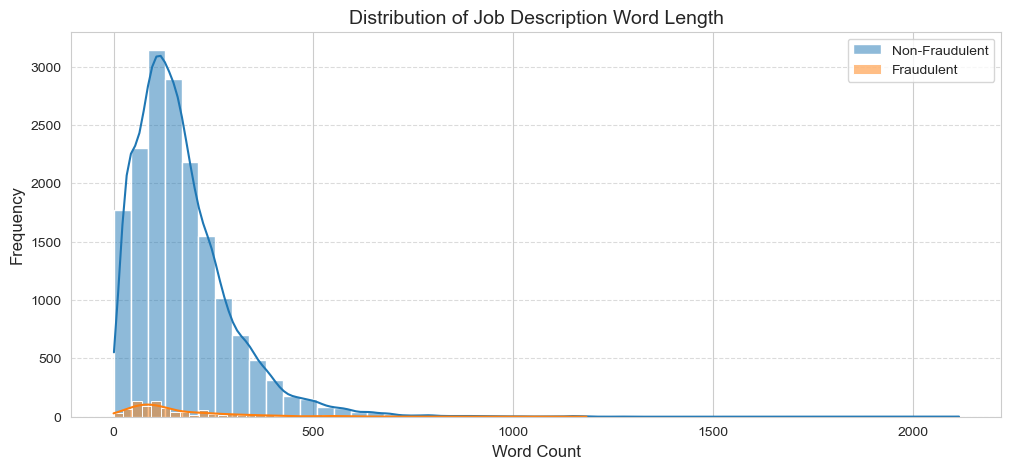

In [21]:
plt.figure(figsize=(12, 5))
sns.histplot(data[data["fraudulent"] == 0]["description"].str.split().str.len(), bins=50, kde=True, color='#1f77b4', label="Non-Fraudulent")
sns.histplot(data[data["fraudulent"] == 1]["description"].str.split().str.len(), bins=50, kde=True, color='#ff7f0e', label="Fraudulent")

plt.title("Distribution of Job Description Word Length", fontsize=14)
plt.xlabel("Word Count", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


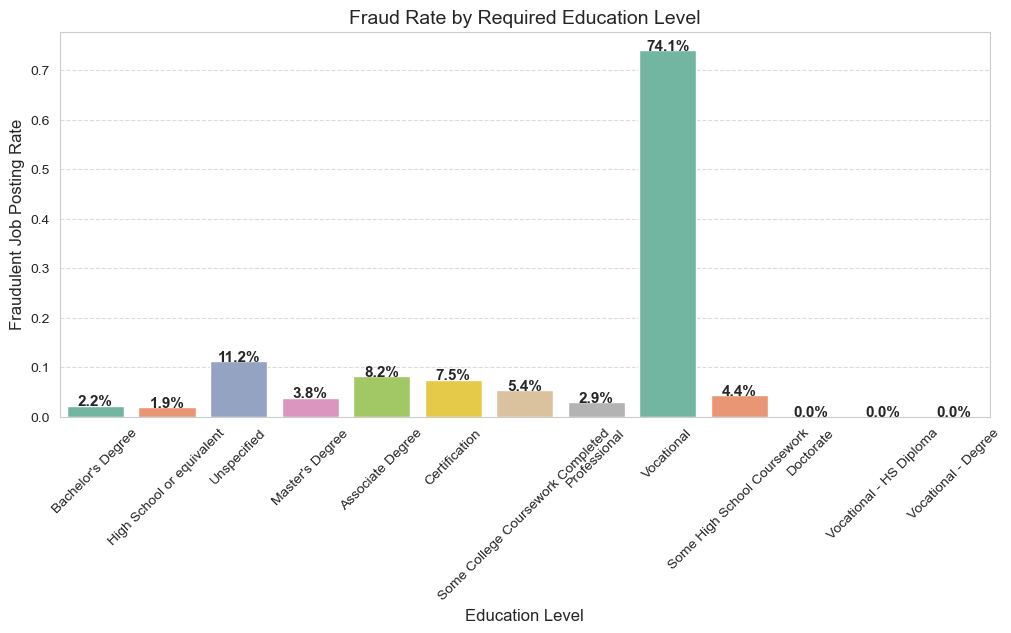

In [22]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(x=data["required_education"].value_counts().index, 
                 y=data.groupby("required_education")["fraudulent"].mean(), 
                 palette="Set2")

plt.title("Fraud Rate by Required Education Level", fontsize=14)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Fraudulent Job Posting Rate", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add percentage labels
for p in ax.patches:
    ax.annotate(f"{100 * p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha="center", fontsize=11, fontweight="bold")

plt.show()


## Finding top 30 suspicios words from each text cols

In [23]:
import pandas as pd
import re
import nltk
from bs4 import BeautifulSoup
import contractions
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import words

# Download the English words list for gibberish detection
nltk.download('words')
english_vocab = set(words.words())

# Function to detect gibberish (random text)
def is_gibberish(word):
    # Remove words with too many numbers or repeated characters
    if re.fullmatch(r"[a-zA-Z]*\d+[a-zA-Z]*", word) or re.fullmatch(r"(.)\1{3,}", word):
        return True
    # Check if the word is in the English dictionary
    if word.lower() not in english_vocab and len(word) > 3:  
        return True  # Likely gibberish if it's long & not in dictionary
    return False

# Function to preprocess text (expand contractions, remove HTML, URLs, gibberish, special characters)
def preprocess_text(text):
    if pd.isnull(text):  
        return []
    
    # Expand contractions (e.g., "can't" → "cannot")
    text = contractions.fix(text)
    
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Remove URLs & email addresses
    text = re.sub(r'http\S+|www\S+|@\S+', '', text)

    # Remove extra spaces & special characters (keeping words intact)
    text = re.sub(r'\s+', ' ', text).strip()

    # Convert to lowercase
    text = text.lower()

    # Split text into words
    words_list = text.split()

    # Remove gibberish words
    words_list = [word for word in words_list if not is_gibberish(word)]

    # Remove stopwords (optional, depending on your dataset and needs)
    words_list = [word for word in words_list if word not in ENGLISH_STOP_WORDS]

    return words_list

# Define the text-based columns we want to analyze separately
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

# Check if the dataset has a 'fraudulent' column
if 'fraudulent' not in data.columns:
    raise ValueError("Dataset does not contain a 'fraudulent' column.")

# Create a dictionary to store suspicious keywords for each column
suspicious_keywords_per_column = {}

# Process each column separately
for col in text_columns:
    print(f"Processing column: {col}")
    
    # Apply preprocessing
    data[f'processed_{col}'] = data[col].apply(preprocess_text)  

    # Separate fraudulent and legitimate job posts
    fraudulent_jobs = data[data['fraudulent'] == 1]
    legitimate_jobs = data[data['fraudulent'] == 0]

    # Count word frequencies in fraudulent and legitimate job posts
    fraudulent_words = Counter([word for words in fraudulent_jobs[f'processed_{col}'] for word in words])
    legitimate_words = Counter([word for words in legitimate_jobs[f'processed_{col}'] for word in words])

    # Identify suspicious words (appear more in fraudulent jobs than legitimate ones)
    suspicious_keywords = {word: count for word, count in fraudulent_words.items() if count > legitimate_words.get(word, 0)}

    # Store top 30 suspicious words for this column
    suspicious_keywords_per_column[col] = sorted(suspicious_keywords.items(), key=lambda x: x[1], reverse=True)[:30]

# Print results for each column
for col, keywords in suspicious_keywords_per_column.items():
    print(f"\nTop 30 Suspicious Keywords in '{col}':")
    print([word for word, count in keywords])


[nltk_data] Downloading package words to
[nltk_data]     C:\Users\samar\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


Processing column: title
Processing column: company_profile
Processing column: description
Processing column: requirements
Processing column: benefits

Top 30 Suspicious Keywords in 'title':
['payroll', 'based', 'earn', 'daily', 'cash', 'cruise', 'subsea', 'ust', 'iii', 'money', 'optical', 'lawn', 'weekly', 'clerical', 'typist', 'preservation', 'instrument', 'surgical', 'optician', 'hand', 'urgently', 'offshore', 'document', 'hma', 'smb', 'enroll', 'cell', 'hse', 'discipline', 'architectural']

Top 30 Suspicious Keywords in 'company_profile':
['bonus', 'referral', 'aptitude', 'refined', 'hired', 'package', 'town', 'participate', 'effort', 'novation', 'pleasant', 'be!', '(if', 'duration', 'newly', 'recovery', 'petroleum', 'vp', 'uhc', 'unmatched', 'cell', 'cartwright', 'hoa', '(in', '[', 'enlarge', ']', 'aggressive', 'oak', 'tree']

Top 30 Suspicious Keywords in 'description':
['oil', 'gas', 'subsea', 'petroleum', 'hse', '6*', 'ultra', 'cruise', 'housekeeping', 'wages', 'appraisal', 'di

# 🧾 Code Summary: Data Preprocessing for Fraudulent Job Detection

- 📥 **Import Libraries**
  - Uses `pandas` for data manipulation.

---

## 1️⃣ Missing Values Handling

- 🔍 Checks for missing values and displays:
  - Total missing values per column.
  - Percentage of missing values per column.
- 📉 Sets a threshold (30% of total columns) to identify rows with excessive missing values.
- 🎯 Focuses only on rows where `fraudulent == 0`.
- 🧹 Drops rows that exceed the missing value threshold.

---

## 2️⃣ Data Balancing

- ⚖️ Defines a target of 1000 samples for the non-fraudulent class.
- 📊 Separates data into:
  - Non-fraudulent rows (`fraudulent == 0`)
  - Fraudulent rows (`fraudulent == 1`)
- 🔁 Randomly samples 1000 rows from non-fraudulent data (if more are available).
- ➕ Combines both classes into a balanced dataset.
- 🆕 Resets the index of the new balanced DataFrame.

---

## 3️⃣ Missing Value Imputation

- 📝 Fills missing values in **text columns** (`title`, `description`, etc.) with `'Missing'`.
- 📍 Fills missing **categorical fields** with descriptive placeholders like `'Unknown'` or `'Not Specified'`.
- 📈 Prints updated percentages of missing values post-imputation.

---

## 4️⃣ Column Dropping

- 🗑️ Drops irrelevant or less useful columns:
  - `department`, `salary_range`, `location`, `job_id`
- 👁️ Displays a sample of the cleaned data.

---

## 5️⃣ Class Distribution Check

- 📦 Shows the distribution of the `fraudulent` column to ensure class balance.
  - Useful for validating effectiveness of balancing step.

---


In [24]:
# Import necessary libraries
import pandas as pd

# -------------------------
# 1. MISSING VALUES HANDLING
# -------------------------

# Check for missing values
print("\nMissing Values in Each Column:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

# View percentage of missing values per column
print('\nPercent of Null Values in Each Column:')
print(data.isnull().mean() * 100)

# Define threshold for missing values (30% of total columns)
threshold = 0.1 * data.shape[1]

# Filter rows where fraudulent = 0
fraudulent_0 = data[data['fraudulent'] == 0]

# Count missing values per row
missing_counts = fraudulent_0.isnull().sum(axis=1)

# Identify and drop rows with missing values exceeding the threshold
rows_to_drop = fraudulent_0[missing_counts > threshold].index
data = data.drop(index=rows_to_drop)

print(f"\nDropped {len(rows_to_drop)} rows with more than 30% missing values where fraudulent = 0")

# -------------------------
# 2. DATA BALANCING
# -------------------------

# Define the target count for fraudulent = 0
target_count = 1000

# Filter fraudulent = 0 and 1 separately
fraudulent_0 = data[data['fraudulent'] == 0]
fraudulent_1 = data[data['fraudulent'] == 1]

# Randomly sample rows from fraudulent_0 to match the target count
if len(fraudulent_0) > target_count:
    fraudulent_0 = fraudulent_0.sample(n=target_count, random_state=42)

# Combine the balanced data
data_balanced = pd.concat([fraudulent_0, fraudulent_1])

# Reset index
data = data_balanced.reset_index(drop=True)

print(f"\nFinal dataset shape: {data_balanced.shape}")

# -------------------------
# 3. MISSING VALUE IMPUTATION
# -------------------------

# Replace missing values in text columns with 'Missing'
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']
data[text_columns] = data[text_columns].fillna('Missing')

# Replace missing values in categorical columns with placeholders
data['location'].fillna('Unknown', inplace=True)
data['employment_type'].fillna('Not Specified', inplace=True)
data['required_experience'].fillna('Not Specified', inplace=True)
data['required_education'].fillna('Not Specified', inplace=True)
data['industry'].fillna('Not Specified', inplace=True)
data['function'].fillna('Not Specified', inplace=True)

# Check the updated missing data percentages
print("\nPercentage of Missing Values After Imputation:")
print(data.isnull().mean() * 100)

# -------------------------
# 4. COLUMN DROPPING
# -------------------------

# Drop unnecessary columns
columns_to_drop = ['department', 'salary_range', 'location', 'job_id']
data = data.drop(columns=columns_to_drop, errors='ignore')

# Verify the changes
print("\nSample Data After Dropping Columns:")
print(data.head())

# -------------------------
# 5. CLASS DISTRIBUTION CHECK
# -------------------------

# Check class distribution (fraudulent vs non-fraudulent jobs)
if 'fraudulent' in data.columns:
    class_distribution = data['fraudulent'].value_counts()
    print("\nClass Distribution (Fraudulent vs Non-Fraudulent):")
    print(class_distribution)


Missing Values in Each Column:
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
dtype: int64

Percent of Null Values in Each Column:
job_id                        0.000000
title                         0.000000
location                      1.935123
department                   64.580537
salary_range                 83.959732
company_profile              18.501119
description                   0.005593
requirements                 15.078300
benefits                     40.335570
telecommuting                 0.000000
has_company_logo              0.000000
has_questions                 0.000000
employment_type              19.412752
required_experience          39.429530
required_education   

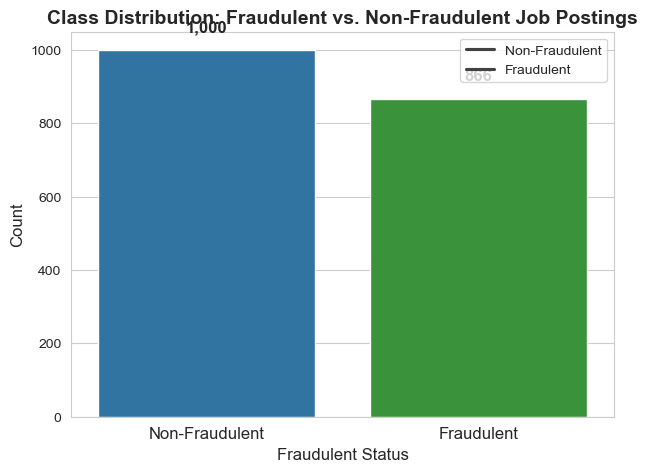

In [25]:
# Set industry-standard style
sns.set_style("whitegrid")

# Define colors (blue & green - industry standard for trust & safety)
colors = ["#1f77b4", "#2ca02c"]  

# Create figure
plt.figure(figsize=(7, 5))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette=colors)

# Add annotations on bars
for i, val in enumerate(class_distribution.values):
    plt.text(i, val + 50, f"{val:,}", ha="center", fontsize=12, fontweight="bold")

# Set title and labels
plt.title("Class Distribution: Fraudulent vs. Non-Fraudulent Job Postings", fontsize=14, fontweight="bold")
plt.xlabel("Fraudulent Status", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Set custom x-axis labels
plt.xticks(ticks=[0, 1], labels=["Non-Fraudulent", "Fraudulent"], fontsize=12)

# Add a legend
plt.legend(["Non-Fraudulent", "Fraudulent"], loc="upper right", frameon=True)

# Show plot
plt.show()


## Define Preprocessing Function

In [27]:
def is_gibberish(word):
    """Check if a word is gibberish."""
    # Remove words with too many numbers or repeated characters
    if re.fullmatch(r"[a-zA-Z]*\d+[a-zA-Z]*", word) or re.fullmatch(r"(.)\1{3,}", word):
        return True
    # Check if the word is in the English dictionary and is sufficiently long
    if word.lower() not in english_vocab and len(word) > 3:
        return True  # Likely gibberish if it's long & not in dictionary
    return False

def preprocess_text(text):
    """Text preprocessing pipeline with cleaning, gibberish detection, and lemmatization."""
    # Step 1: Lowercasing
    text = text.lower()
    
    # Step 2: Remove HTML tags using BeautifulSoup
    text = BeautifulSoup(text, "html.parser").get_text()
    
    # Step 3: Expand contractions (e.g., "I'm" -> "I am")
    text = contractions.fix(text)
    
    # Step 4: Remove non-alphabetic characters (optional, depending on your needs)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Step 5: Tokenize text into words
    words_in_text = text.split()
    
    # Step 6: Lemmatize and remove gibberish
    cleaned_words = []
    for word in words_in_text:
        # Lemmatize the word
        lemmatized_word = lemmatizer.lemmatize(word)
        
        # Remove gibberish words (those not in the English vocabulary)
        if lemmatized_word not in stop_words and not is_gibberish(lemmatized_word):
            cleaned_words.append(lemmatized_word)
    
    # Step 7: Recombine cleaned words into a single string
    return " ".join(cleaned_words)

# 🧹 Text Preprocessing & Gibberish Detection Summary

## 🔍 Function: `is_gibberish(word)`
- 📌 Identifies gibberish words using specific rules:
  - ✅ Flags words with **excessive digits or repeated characters**, using regex:
    - Examples: `"abc123"`, `"zzzzz"`, etc.
  - ✅ Flags words **longer than 3 characters** that are **not found in a standard English vocabulary list**.
  - ❌ Allows valid short or meaningful words.
- 📤 Returns `True` if the word is likely gibberish; `False` otherwise.

---

## 🧼 Function: `preprocess_text(text)`
- Performs a **comprehensive text cleaning pipeline**, including normalization, gibberish removal, and lemmatization.

### Step-by-step:

- 🔡 **Lowercasing**:
  - Converts all characters to lowercase for uniformity.

- 🏷️ **HTML Tag Removal**:
  - Uses `BeautifulSoup` to strip out HTML content.

- 🔄 **Contraction Expansion**:
  - Expands phrases like `"I'm"` to `"I am"` using `contractions.fix()`.

- ❌ **Non-Alphabetic Character Removal**:
  - Strips out punctuation, numbers, and special symbols using regex.

- ✂️ **Tokenization**:
  - Splits the cleaned string into individual words.

- 🧠 **Lemmatization & Gibberish Removal**:
  - Lemmatizes each word (e.g., `"running"` → `"run"`).
  - Filters out:
    - Stop words.
    - Gibberish words (via `is_gibberish()`).

- 🔁 **Reconstruction**:
  - Joins cleaned and filtered words back into a single string.

---

🧠 **Purpose**: Prepares raw textual job descriptions (or similar data) for machine learning by reducing noise, filtering irrelevant tokens, and standardizing inputs.


## Final Logistic Model


Selected Features for Model: ['title', 'company_profile', 'description', 'requirements', 'benefits', 'industry', 'function', 'required_experience', 'has_company_logo', 'required_education']

Cross-validation scores: [0.96524064 0.96782842 0.97855228 0.9463807  0.96246649]
Average cross-validation score: 0.9641


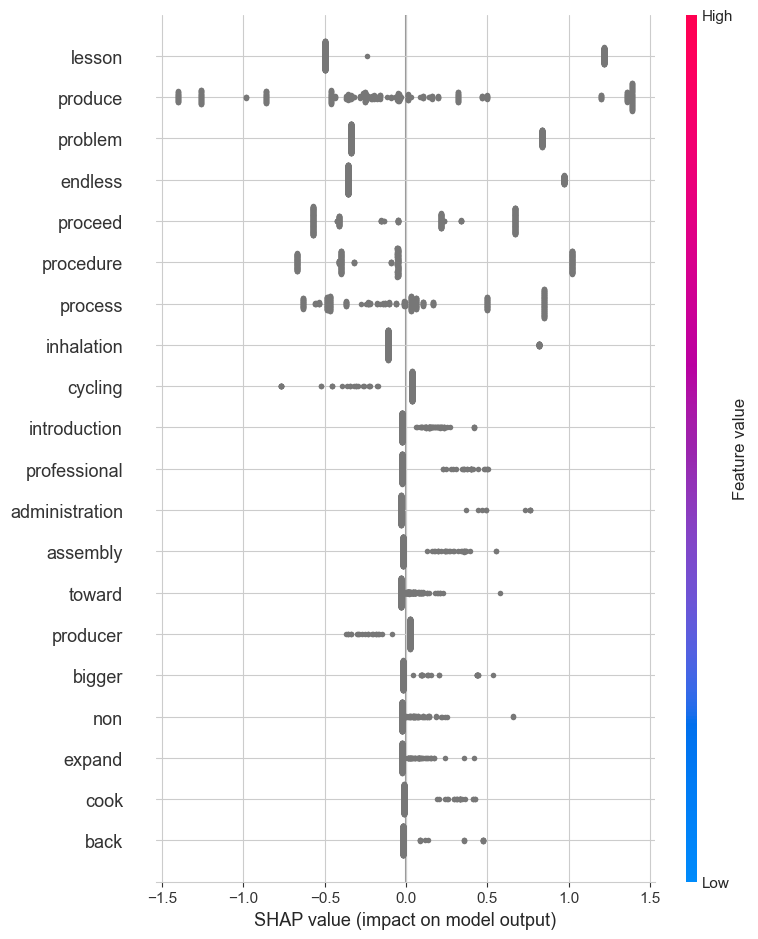

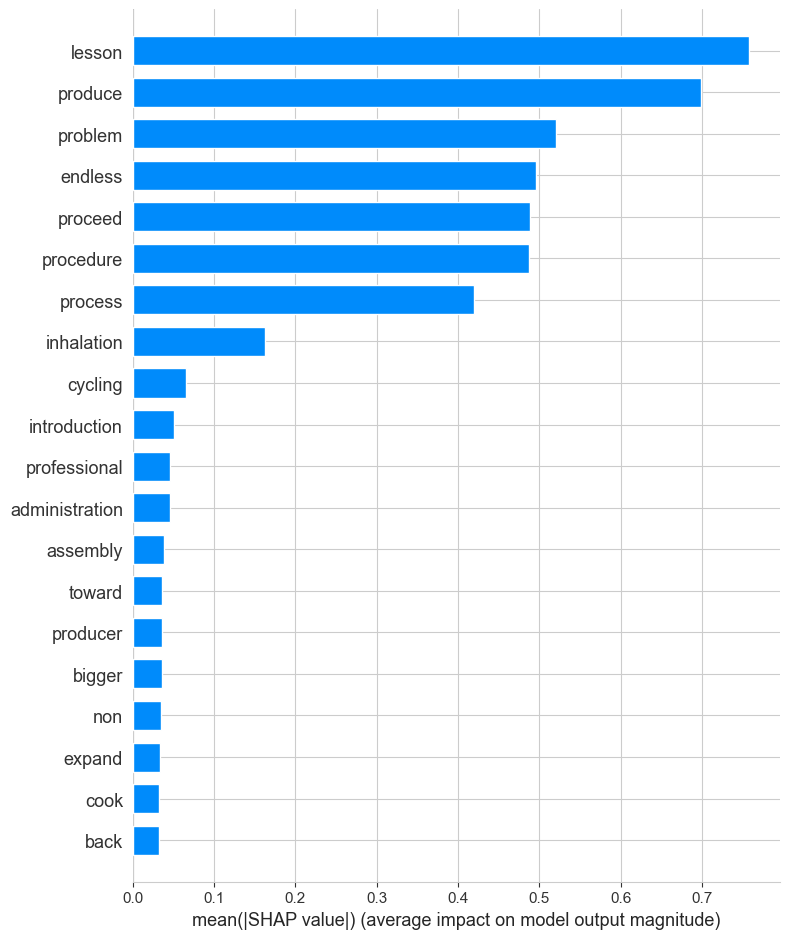


Model Performance:
Accuracy: 0.9759
Precision: 0.9820
Recall: 0.9647
F1 Score: 0.9733



Example Predictions with Scam Severity Scores:

      True Label  Predicted Label  Scam Severity Score
1697           1                1             0.999463
1680           1                1             0.994788
921            0                0             0.005411
275            0                0             0.036547
416            0                0             0.033265


In [28]:
# Define feature categories
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']
categorical_columns = ['employment_type', 'required_experience', 'required_education', 'function', 'industry']
numerical_columns = ['telecommuting', 'has_company_logo', 'has_questions']

# Preprocess text data
data[text_columns] = data[text_columns].fillna('').applymap(preprocess_text)

# Compute MI scores for categorical and numerical features
X_numerical = data[numerical_columns]
X_categorical = data[categorical_columns].apply(lambda x: x.astype('category').cat.codes)  # Convert categorical to numerical codes
y = data['fraudulent']  # Target variable

mi_numerical = mutual_info_classif(X_numerical, y)
mi_categorical = mutual_info_classif(X_categorical, y)

# Create a DataFrame of MI scores
mi_scores = pd.DataFrame({
    'Feature': numerical_columns + categorical_columns,
    'MI Score': np.concatenate([mi_numerical, mi_categorical])
})

# Define a threshold for MI scores (e.g., 0.1)
mi_threshold = 0.15

# Sort by MI score and select features above the threshold
mi_scores = mi_scores.sort_values(by='MI Score', ascending=False)
top_mi_features = mi_scores[mi_scores['MI Score'] > mi_threshold]['Feature'].tolist()

# Visualization of MI Scores (Plotly)
fig_mi = px.bar(
    mi_scores,
    x='MI Score',
    y='Feature',
    orientation='h',
    color='MI Score',
    color_continuous_scale='Cividis',
    title='Mutual Information Scores for Features'
)
fig_mi.update_layout(yaxis={'categoryorder': 'total ascending'}, width=800, height=500)
fig_mi.show()

# Final selected features: All text columns + Top MI-selected categorical/numerical features
selected_features = text_columns + top_mi_features
print(f"\nSelected Features for Model: {selected_features}\n")

# TF-IDF Vectorization for text data
tfidf_transformers = [(col, TfidfVectorizer(max_features=5000), col) for col in text_columns]

# Define preprocessing pipeline with selected features
preprocessor = ColumnTransformer(
    transformers=tfidf_transformers + [
        ('num', MinMaxScaler(), [f for f in numerical_columns if f in top_mi_features]),  # Only selected numerical features
        ('cat', TargetEncoder(), [f for f in categorical_columns if f in top_mi_features])  # Target Encoding instead of OneHotEncoder
    ]
)

# Model pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    data[selected_features], y, test_size=0.2, random_state=42
)

# Train the model
pipeline.fit(X_train, y_train)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(pipeline, data[selected_features], y, cv=cv, scoring='accuracy')

print(f"Cross-validation scores: {cross_val_scores}")
print(f"Average cross-validation score: {cross_val_scores.mean():.4f}")

# SHAP Analysis
X_train_transformed = pipeline.named_steps['preprocessor'].fit_transform(X_train, y_train)
X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)

# Preprocessing and feature names extraction for TF-IDF (text columns)
feature_names = []
for col, vectorizer, _ in tfidf_transformers:
    vectorizer_fitted = vectorizer.fit(data[col])
    feature_names.extend(vectorizer_fitted.get_feature_names_out())

# Handling numerical feature names
numerical_feature_names = [f for f in numerical_columns if f in top_mi_features]
# After scaling, the numerical feature names need to be preserved
numerical_feature_names_scaled = numerical_feature_names  # After MinMax scaling, these should be the same

# Handling categorical feature names
categorical_feature_names = [f for f in categorical_columns if f in top_mi_features]

# Combine all feature names (text, numerical, and categorical)
all_feature_names = feature_names + numerical_feature_names_scaled + categorical_feature_names

# Ensure SHAP explainer is correctly initialized
explainer = shap.Explainer(pipeline.named_steps['classifier'], X_train_transformed)

# Compute SHAP values
shap_values = explainer(X_test_transformed)

# SHAP summary plot (Matplotlib remains)
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names)

# SHAP bar plot (Matplotlib remains)
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, plot_type="bar")

# Model Evaluation
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# ROC Curve (Plotly)
fpr, tpr, thresholds = roc_curve(y_test, pipeline.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines',
                             name=f'ROC Curve (AUC = {roc_auc:.4f})',
                             line=dict(color='firebrick', width=3)))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                             name='Random Guess',
                             line=dict(color='royalblue', dash='dash')))
fig_roc.update_layout(title='Receiver Operating Characteristic (ROC)',
                      xaxis_title='False Positive Rate',
                      yaxis_title='True Positive Rate',
                      width=600, height=600,
                      template='plotly_white')
fig_roc.show()

# Confusion Matrix (Plotly)
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_df = pd.DataFrame(conf_matrix,
                              index=['Non-Fraud', 'Fraud'],
                              columns=['Non-Fraud', 'Fraud'])

fig_cm = px.imshow(conf_matrix_df,
                   text_auto=True,
                   color_continuous_scale='Blues',
                   title='Confusion Matrix',
                   labels=dict(x="Predicted", y="True", color="Count"))
fig_cm.update_layout(width=600, height=500, template='plotly_white')
fig_cm.show()

# Scam Severity Score based on probability (the probability of being fraudulent)
scam_severity_score = pipeline.predict_proba(X_test)[:, 1]

# Add the scam severity score to the test dataset
X_test['scam_severity_score'] = scam_severity_score

# Display a few example predictions with scam severity score
print(f"\nExample Predictions with Scam Severity Scores:\n")
example_predictions = pd.DataFrame({
    'True Label': y_test,
    'Predicted Label': y_pred,
    'Scam Severity Score': scam_severity_score
})

print(example_predictions.head())


# Random forest with tfidf

In [29]:
# --- Custom Text Preprocessor ---
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.english_vocab = set(words.words())
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def is_gibberish(self, word):
        if re.fullmatch(r"[a-zA-Z]*\d+[a-zA-Z]*", word) or re.fullmatch(r"(.)\1{3,}", word):
            return True
        return word.lower() not in self.english_vocab and len(word) > 3

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return [self._preprocess_text(text) for text in X]

    def _preprocess_text(self, text):
        text = str(text).lower()
        text = BeautifulSoup(text, "html.parser").get_text()
        text = contractions.fix(text)
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        words_in_text = text.split()
        cleaned_words = []
        for word in words_in_text:
            lemmatized = self.lemmatizer.lemmatize(word)
            if lemmatized not in self.stop_words and not self.is_gibberish(lemmatized):
                cleaned_words.append(lemmatized)
        return " ".join(cleaned_words)

# --- Pipeline Construction ---
def create_preprocessing_pipeline(text_columns, cat_columns, num_columns):
    text_transformers = [
        (f'text_{col}', Pipeline([
            ('preprocess', TextPreprocessor()),
            ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english'))
        ]), col) for col in text_columns
    ]

    return ColumnTransformer(
        transformers=[
            *text_transformers,
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns),
            ('num', MinMaxScaler(), num_columns)
        ],
        verbose_feature_names_out=True  # Important for accessing feature names
    )

def create_training_pipeline(preprocessor):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selector', SelectKBest(f_classif, k=100)),  # k can be tuned
        ('classifier', RandomForestClassifier(random_state=42))
    ])

# --- Main Execution ---
if __name__ == "__main__":


    # --- Define Columns ---
    text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
    cat_cols = ['employment_type', 'required_experience', 'required_education', 'function', 'industry']
    num_cols = ['telecommuting', 'has_company_logo', 'has_questions']
    target_col = 'fraudulent'

    # --- Train-Test Split ---
    X = data.drop(columns=[target_col])
    y = data[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- Create Pipelines ---
    preprocessor = create_preprocessing_pipeline(text_cols, cat_cols, num_cols)
    full_pipeline = create_training_pipeline(preprocessor)

    # --- Grid Search ---
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],  # Added 300 estimators
        'classifier__max_depth': [10, 20, None],  # Retain previous depths
        'classifier__min_samples_split': [2, 5, 10],  # Added 10 samples for splitting
        'classifier__min_samples_leaf': [1, 2, 4],  # Added more options for leaf samples
        'classifier__max_features': ['sqrt', 'log2', None],  # Added 'None' for full feature use
        'classifier__bootstrap': [True, False]  # Added bootstrap for sampling options
    }

    grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=1)
    grid_search.fit(X_train, y_train)

    # --- Save Best Model ---
    joblib.dump(grid_search.best_estimator_, 'fraud_detection_pipeline.pkl')

    # --- Evaluation ---
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_probs = best_model.predict_proba(X_test)[:, 1]

    # --- Feature Importance ---
    try:
        selector = best_model.named_steps['feature_selector']
        classifier = best_model.named_steps['classifier']
        preprocessor = best_model.named_steps['preprocessor']
        feature_names = preprocessor.get_feature_names_out()
        selected_mask = selector.get_support()
        selected_features = feature_names[selected_mask]
        importances = classifier.feature_importances_

        importance_df = pd.DataFrame({
            'Feature': selected_features,
            'Importance': importances
        }).sort_values('Importance', ascending=False).head(20)

        fig = px.bar(importance_df, x='Importance', y='Feature', orientation='h', title='Top 20 Important Features')
        fig.show()
    except Exception as e:
        print("Feature importance visualization failed:", e)

    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = roc_auc_score(y_test, y_probs)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC = {roc_auc:.2f})'))
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line_dash='dash', name='Random Baseline'))
    fig.update_layout(title='ROC Curve', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate')
    fig.show()

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    fig = px.imshow(cm, text_auto=True,
                    labels=dict(x="Predicted", y="Actual", color="Count"),
                    x=['Legit', 'Fraud'], y=['Legit', 'Fraud'])
    fig.update_layout(title='Confusion Matrix')
    fig.show()

    # --- Metrics ---
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


[nltk_data] Downloading package words to
[nltk_data]     C:\Users\samar\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\samar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\samar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Fitting 3 folds for each of 486 candidates, totalling 1458 fits
[CV] END classifier__bootstrap=True, classifier__max_depth=10, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   6.6s
[CV] END classifier__bootstrap=True, classifier__max_depth=10, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   5.9s
[CV] END classifier__bootstrap=True, classifier__max_depth=10, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   6.0s
[CV] END classifier__bootstrap=True, classifier__max_depth=10, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=200; total time=   6.4s
[CV] END classifier__bootstrap=True, classifier__max_depth=10, classifier__max_features=sqrt, classifier


Best Parameters: {'classifier__bootstrap': False, 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Accuracy: 0.9733
Precision: 0.9651
Recall: 0.9765
F1 Score: 0.9708
AUC-ROC: 0.9964

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       204
           1       0.97      0.98      0.97       170

    accuracy                           0.97       374
   macro avg       0.97      0.97      0.97       374
weighted avg       0.97      0.97      0.97       374



## Naive Bayes Classifier

In [30]:
# Define feature categories
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']
categorical_columns = ['employment_type', 'required_experience', 'required_education', 'function', 'industry']
numerical_columns = ['telecommuting', 'has_company_logo', 'has_questions']

# Preprocess text data
data[text_columns] = data[text_columns].fillna('').applymap(preprocess_text)

# Compute MI scores for numerical features
X_numerical = data[numerical_columns]
y = data['fraudulent']  # Target variable

mi_numerical = mutual_info_classif(X_numerical, y)

# Chi-Square test for categorical features
X_categorical = data[categorical_columns].apply(lambda x: x.astype('category').cat.codes)  # Convert categorical to numerical codes
chi2_scores, p_values = chi2(X_categorical, y)

# Create a DataFrame for MI and Chi-Square scores
mi_scores = pd.DataFrame({
    'Feature': numerical_columns,
    'MI Score': mi_numerical
})

chi2_scores_df = pd.DataFrame({
    'Feature': categorical_columns,
    'Chi2 Score': chi2_scores,
    'p-value': p_values
})

# Define thresholds
mi_threshold = 0.15
#chi2_p_threshold = 0.05

# Sort by MI score and Chi-Square score and apply thresholds
mi_scores = mi_scores.sort_values(by='MI Score', ascending=False)
selected_mi_features = mi_scores[mi_scores['MI Score'] > mi_threshold]['Feature'].tolist()

chi2_scores_df = chi2_scores_df.sort_values(by='Chi2 Score', ascending=False)
chi2_p_threshold = 0.01 
selected_chi2_features = chi2_scores_df[chi2_scores_df['p-value'] < chi2_p_threshold]['Feature'].tolist()


# Visualization of MI and Chi-Square Scores (Plotly)
fig_mi = px.bar(
    mi_scores,
    x='MI Score',
    y='Feature',
    orientation='h',
    color='MI Score',
    color_continuous_scale='Cividis',
    title='Mutual Information Scores for Numerical Features'
)

fig_mi.update_layout(yaxis={'categoryorder': 'total ascending'}, width=800, height=500)
fig_mi.show()

fig_chi2 = px.bar(
    chi2_scores_df,
    x='Chi2 Score',
    y='Feature',
    orientation='h',
    color='Chi2 Score',
    color_continuous_scale='Cividis',
    title='Chi-Square Scores for Categorical Features'
)

fig_chi2.update_layout(yaxis={'categoryorder': 'total ascending'}, width=800, height=500)
fig_chi2.show()

# Final selected features (combine text features + top MI and Chi-Square selected features)
selected_features = text_columns + selected_mi_features + selected_chi2_features

print(f"\nSelected Features for Model: {selected_features}\n")

# TF-IDF Vectorization for text data
tfidf_transformers = [(col, TfidfVectorizer(max_features=5000), col) for col in text_columns]

# Define preprocessing pipeline with selected features
preprocessor = ColumnTransformer(
    transformers=tfidf_transformers + [
        ('num', MinMaxScaler(), [f for f in numerical_columns if f in selected_mi_features]),  # Only selected numerical features
        ('cat', TargetEncoder(), [f for f in categorical_columns if f in selected_chi2_features])  # Target Encoding for categorical features
    ]
)

# Model pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MultinomialNB())  # You can switch to GaussianNB for continuous numerical data
])

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    data[selected_features], y, test_size=0.2, random_state=42
)

# Train the model
pipeline.fit(X_train, y_train)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(pipeline, data[selected_features], y, cv=cv, scoring='accuracy')

print(f"Cross-validation scores: {cross_val_scores}")
print(f"Average cross-validation score: {cross_val_scores.mean():.4f}")

# Model Evaluation
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# ROC Curve (Plotly)
fpr, tpr, thresholds = roc_curve(y_test, pipeline.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines',
                             name=f'ROC Curve (AUC = {roc_auc:.4f})',
                             line=dict(color='firebrick', width=3)))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                             name='Random Guess',
                             line=dict(color='royalblue', dash='dash')))

fig_roc.update_layout(title='Receiver Operating Characteristic (ROC)',
                     xaxis_title='False Positive Rate',
                     yaxis_title='True Positive Rate',
                     width=600, height=600,
                     template='plotly_white')
fig_roc.show()

# Confusion Matrix (Plotly)
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_df = pd.DataFrame(conf_matrix,
                             index=['Non-Fraud', 'Fraud'],
                             columns=['Non-Fraud', 'Fraud'])

fig_cm = px.imshow(conf_matrix_df,
                   text_auto=True,
                   color_continuous_scale='Blues',
                   title='Confusion Matrix',
                   labels=dict(x="Predicted", y="True", color="Count"))

fig_cm.update_layout(width=600, height=500, template='plotly_white')
fig_cm.show()

# Scam Severity Score based on probability (the probability of being fraudulent)
scam_severity_score = pipeline.predict_proba(X_test)[:, 1]

# Add the scam severity score to the test dataset
X_test['scam_severity_score'] = scam_severity_score

# Display a few example predictions with scam severity score
print(f"\nExample Predictions with Scam Severity Scores:\n")
example_predictions = pd.DataFrame({
    'True Label': y_test,
    'Predicted Label': y_pred,
    'Scam Severity Score': scam_severity_score
})
print(example_predictions.head())


Selected Features for Model: ['title', 'company_profile', 'description', 'requirements', 'benefits', 'has_company_logo', 'industry', 'function', 'required_education', 'required_experience', 'employment_type']

Cross-validation scores: [0.93582888 0.92761394 0.94101877 0.91420912 0.94101877]
Average cross-validation score: 0.9319

Model Performance:
Accuracy: 0.9519
Precision: 0.9471
Recall: 0.9471
F1 Score: 0.9471



Example Predictions with Scam Severity Scores:

      True Label  Predicted Label  Scam Severity Score
1697           1                1             0.998390
1680           1                1             0.984460
921            0                0             0.000503
275            0                0             0.127588
416            0                0             0.221128


## Glove with xg boost

In [31]:
# Function to load GloVe embeddings
def load_glove_embeddings(glove_file):
    embeddings = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

# Convert text to GloVe word vectors
def text_to_glove_vectors(text, glove_embeddings):
    words = preprocess_text(text).split()
    vectors = [glove_embeddings.get(word, np.zeros(100)) for word in words]  # Use zero vector for OOV words
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(100)  # Handle empty input

# Load GloVe embeddings
glove_file = ('glove.6B.100d.txt')
glove_embeddings = load_glove_embeddings(glove_file)

In [32]:
# Columns in dataset
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']
categorical_columns = ['employment_type', 'required_experience', 'required_education', 'function', 'industry']
numerical_columns = ['telecommuting', 'has_company_logo', 'has_questions']

# Store original title column for later use
original_title = data['title']

# Convert text columns to GloVe embeddings
for col in text_columns:
    data[f'glove_{col}'] = data[col].fillna('').apply(lambda x: text_to_glove_vectors(x, glove_embeddings))

# Create feature set
X = data[[f'glove_{col}' for col in text_columns] + categorical_columns + numerical_columns]
y = data['fraudulent']  # Target variable

In [33]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_columns),
        ('cat', TargetEncoder(), categorical_columns)  # Use Target Encoder
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss'))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 6],
    'classifier__learning_rate': [0.01, 0.1]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='roc_auc', verbose=2)
grid_search.fit(X_train, y_train)

print("Best parameters from GridSearchCV: ", grid_search.best_params_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters from GridSearchCV:  {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 200}


                                            glove_title  \
1697  [0.22115, 0.027844, -0.053894, -0.47618, -0.36...   
1680  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
921   [0.14726, 0.088411, 0.28386, -0.2797, -0.32498...   
275   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
416   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   

                                  glove_company_profile  \
1697  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
1680  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
921   [-0.025274428, 0.26093256, 0.3134914, -0.07994...   
275   [-0.19552264, 0.058332518, 0.41368073, 0.01051...   
416   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   

                                      glove_description  \
1697  [0.12816802, 0.27899656, 0.3698732, -0.315411,...   
1680  [-0.18201628, -0.021588283, 0.23178457, -0.031...   
921   [-0.14069276, 0.33227962, 0.31661692, -0.21047...   
275   [-0.0930287, -0.26470733, 0.051590692, -0.0441..

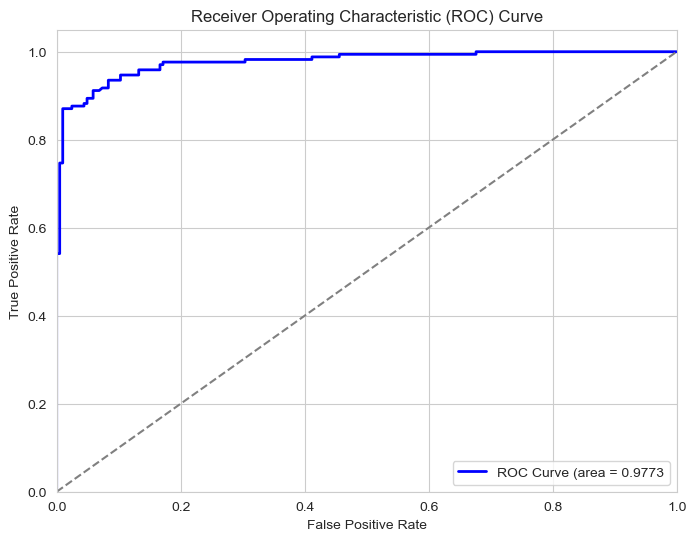

In [35]:
y_probs = grid_search.predict_proba(X_test)[:, 1]
y_pred = grid_search.predict(X_test)

scaler = MinMaxScaler(feature_range=(0, 100))
scam_severity_score = scaler.fit_transform(y_probs.reshape(-1, 1))

result_df = pd.DataFrame(X_test, columns=[f'glove_{col}' for col in text_columns] + categorical_columns + numerical_columns)
result_df['true_label'] = y_test
result_df['predicted_label'] = y_pred
result_df['fraud_probability'] = y_probs
result_df['scam_severity_score'] = scam_severity_score.flatten()

print(result_df.head())

roc_auc = roc_auc_score(y_test, y_probs)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

cv_scores = cross_val_score(grid_search.best_estimator_, X, y, cv=5, scoring='roc_auc')
print(f"\nCross-Validation ROC AUC Scores: {cv_scores}")
print(f"Mean Cross-Validation ROC AUC: {cv_scores.mean():.4f}")

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (area = {roc_auc_val:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()